##**Factors Influencing Financial Inclusion in the Philippines**

Overview

This notebook analyzes the Global Findex 2025 dataset stored in Google BigQuery.

 Research Questions

**1.** **What is the level of financial inclusion among Filipino adults?**

**2.** **How does financial inclusion differ across demographic groups?**

**3.** **Which demographic characteristics are associated with financial account ownership?**

In [ ]:
##Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import auth
from google.cloud import bigquery

# Authenticate
auth.authenticate_user()

# Connect to BigQuery
client = bigquery.Client(project="sprint-2-final-day-project")

query = """
SELECT *
FROM `sprint-2-final-day-project.findex_dataset.findex_microdata_2025_labelled_update112425`
"""

data = client.query(query).to_dataframe()


##Data Understanding

The dataset was imported directly from Google BigQuery and contains responses from the Global Findex 2025 survey. **This analysis focuses on Filipino respondents to examine factors influencing financial inclusion.**

Before conducting the analysis, the dataset is explored to understand its structure, variables, and data quality.

In [ ]:
print(data.shape)

(144090, 199)


In [ ]:
data.head()

,year,economy,economycode,regionwb,pop_adult,wpid_random,wgt,female,age,educ,inc_q,emp_in,urbanicity,account_fin,account_mob,account,dig_account,borrowed,saved,receive_wages,receive_transfers,receive_pensions,receive_agriculture,merchantpay_dig,pay_utilities,domestic_remittances,anydigpayment,fin2,fin3,fin4,fin5,fin6,fin7,fin8,fin9a,fin9b,fin10,fin11_0,fin11_1,fin11_2,fin11a,fin11b,fin11c,fin11d,fin11e,fin11f,fin13_1,fin13a,fin13b,fin13c,fin13d,fin13e,fin13f,fin13f_1,fin14a,fin14b,fin14c,fin14d,fin14e,fin15,fin16,fin17a,fin17b,fin17c,fin17d,fin17e,fin17f,fin18,fin19,fin20,fin21,fin22a,fin22a_1,fin22b,fin22c,fin22d,fin22e,fin22f,fin22g,fin22h,fin23,fin24,fin24a,fin24b,fin24c,fin24d1,fin24d2,fin24d3,fin25e1,fin25e2,fin25e3,fin25e4,fin26a,fin26b,fin27,fh1,fin28,fh2,fin29,fh2a,fin30,fin31a,fin31b,fin31c,fin31d,fin32,fin33,fin34a,fin34b,fin34c,fin34d,fin35,fin36,fin36a,fin37,fin38,fin39a,fin39b,fin39c,fin39d,fin40,fin41,fin41a,fin42,fin43a,fin43b,fin43c,fin43d,fin44,fin45,internet_use,con1,con2a,con2b,con2c,con2d,con2e,con2f,con2g,con3,con4,con5,con6,con7,con8,con9,con10,con11,con12,con13,con14,con15,con16,con17,con18,con19,con20,con21,con22,con23,con24,con25,con26,con27,con28,con29,con30a,con30b,con30c,con30d,con30e,con30f,con30g,con30h,con31a,con31b,con31c,con31d,con31e,con31f,con31g,con31h,con32,fin46,fin47,fin48a,fin48b,fin48c,fin48d,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Montenegro,MNE,Europe & Central Asia (excluding high income),503215,169905782,0.859767,1,40,2,5,1,1,1,<NA>,1,0,0,0,5,5,5,5,0,5,4,0,2,2,1,6,6,4,4,4,4,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4,<NA>,4,<NA>,<NA>,<NA>,4,4,4,<NA>,4,<NA>,4,<NA>,4,4,4,<NA>,<NA>,4,9,<NA>,6,2,<NA>,<NA>,<NA>,4,4,<NA>,7,4,4,<NA>,4,<NA>,4,<NA>,4,4,<NA>,<NA>,<NA>,<NA>,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4,4,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4,<NA>,<NA>,<NA>,<NA>,<NA>,3,1,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,2
1,2024,Montenegro,MNE,Europe & Central Asia (excluding high income),503215,203995311,1.105034,2,48,3,1,1,1,1,<NA>,1,1,1,1,1,4,4,4,0,2,2,1,1,1,2,2,2,<NA>,2,1,1,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,2,<NA>,<NA>,<NA>,1,1,2,<NA>,1,<NA>,2,<NA>,2,1,2,1,2,<NA>,3,2,4,2,<NA>,<NA>,<NA>,2,3,<NA>,3,2,2,<NA>,1,2,2,<NA>,2,1,2,2,<NA>,1,1,1,1,2,<NA>,<NA>,2,1,<NA>,2,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,<NA>,<NA>,<NA>,<NA>,1,1,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,2
2,2024,Comoros,COM,Sub-Saharan Africa (excluding high income),532331,111593248,2.352998,2,15,1,1,2,1,1,0,1,0,1,1,4,5,4,4,0,4,3,1,2,2,1,2,2,<NA>,2,1,1,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,2,1,1,1,1,1,1,<NA>,1,2,1,1,<NA>,2,1,1,1,<NA>,1,1,1,1,1,<NA>,<NA>,<NA>,5,1,2,1,2,1,1,1,3,<NA>,4,1,1,2,2,<NA>,2,<NA>,2,2,<NA>,<NA>,<NA>,<NA>,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,<NA>,<NA>,<NA>,<NA>,4,0,2,1,2,2,2,2,1,2,1,2,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,1,1,1,1,1,1,1,1,1,1,2,1,<NA>,<NA>
3,2024,Comoros,COM,Sub-Saharan Africa (excluding high income),532331,139848347,1.568666,2,15,2,2,2,1,1,0,1,1,1,0,4,4,4,2,0,2,3,0,2,1,1,

In [ ]:
# View column names and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144090 entries, 0 to 144089
Columns: 199 entries, year to fin51
dtypes: Int64(195), float64(1), object(3)
memory usage: 245.6+ MB


In [ ]:
# Summary statistics
data.describe()

,year,pop_adult,wpid_random,wgt,female,age,educ,inc_q,emp_in,urbanicity,account_fin,account_mob,account,dig_account,borrowed,saved,receive_wages,receive_transfers,receive_pensions,receive_agriculture,merchantpay_dig,pay_utilities,domestic_remittances,anydigpayment,fin2,fin3,fin4,fin5,fin6,fin7,fin8,fin9a,fin9b,fin10,fin11_0,fin11_1,fin11_2,fin11a,fin11b,fin11c,fin11d,fin11e,fin11f,fin13_1,fin13a,fin13b,fin13c,fin13d,fin13e,fin13f,fin13f_1,fin14a,fin14b,fin14c,fin14d,fin14e,fin15,fin16,fin17a,fin17b,fin17c,fin17d,fin17e,fin17f,fin18,fin19,fin20,fin21,fin22a,fin22a_1,fin22b,fin22c,fin22d,fin22e,fin22f,fin22g,fin22h,fin23,fin24,fin24a,fin24b,fin24c,fin24d1,fin24d2,fin24d3,fin25e1,fin25e2,fin25e3,fin25e4,fin26a,fin26b,fin27,fh1,fin28,fh2,fin29,fh2a,fin30,fin31a,fin31b,fin31c,fin31d,fin32,fin33,fin34a,fin34b,fin34c,fin34d,fin35,fin36,fin36a,fin37,fin38,fin39a,fin39b,fin39c,fin39d,fin40,fin41,fin41a,fin42,fin43a,fin43b,fin43c,fin43d,fin44,fin45,internet_use,con1,con2a,con2b,con2c,con2d,con2e,con2f,con2g,con3,con4,con5,con6,con7,con8,con9,con10,con11,con12,con13,con14,con15,con16,con17,con18,con19,con20,con21,con22,con23,con24,con25,con26,con27,con28,con29,con30a,con30b,con30c,con30d,con30e,con30f,con30g,con30h,con31a,con31b,con31c,con31d,con31e,con31f,con31g,con31h,con32,fin46,fin47,fin48a,fin48b,fin48c,fin48d,fin48e,fin48f,fin49a,fin49b,fin49c,fin49d,fin49e,fin49f,fin50,fin51
count,144090.0,144090.0,144090.0,144090.000000,144090.0,144090.0,143502.0,143070.0,140070.0,141564.0,144090.0,81924.0,144090.0,102954.0,102954.0,102954.0,91901.0,91901.0,91901.0,91901.0,102954.0,91901.0,132273.0,102954.0,144090.0,53308.0,53308.0,44605.0,44605.0,10225.0,53308.0,53308.0,53308.0,53308.0,22273.0,22273.0,22273.0,22273.0,22273.0,22273.0,22273.0,22273.0,22273.0,9633.0,16410.0,16410.0,16410.0,16410.0,16410.0,16410.0,4305.0,15100.0,15100.0,15100.0,15100.0,15100.0,15100.0,15100.0,102954.0,29567.0,102954.0,26168.0,31417.0,31417.0,63399.0,102954.0,102954.0,9691.0,102954.0,29567.0,102954.0,16444.0,102954.0,102954.0,91901.0,11798.0,8439.0,56300.0,102954.0,93428.0,102954.0,102954.0,24335.0,24335.0,15358.0,58926.0,67915.0,30391.0,35219.0,67915.0,67915.0,20594.0,91901.0,24091.0,91901.0,28314.0,91901.0,91901.0,46048.0,46048.0,1675.0,25580.0,91901.0,28059.0,28059.0,28059.0,9749.0,1093.0,18570.0,18570.0,36.0,91901.0,91901.0,17342.0,17342.0,6250.0,3326.0,11711.0,11711.0,970.0,91901.0,13885.0,13885.0,10157.0,868.0,13885.0,102954.0,144090.0,144090.0,12235.0,12235.0,12235.0,12235.0,12235.0,12235.0,12235.0,11376.0,12235.0,5275.0,5275.0,5275.0,6960.0,86358.0,19430.0,64663.0,64663.0,1727.0,64663.0,3067.0,51145.0,64663.0,64663.0,39010.0,64663.0,64663.0,14359.0,64663.0,144090.0,42248.0,47986.0,47986.0,36722.0,11264.0,51839.0,51839.0,51839.0,51839.0,51839.0,51839.0,51839.0,51839.0,19717.0,19717.0,19717.0,19717.0,19717.0,19717.0,19717.0,19717.0,18633.0,126323.0,81034.0,8037.0,8037.0,8037.0,8037.0,8037.0,8037.0,8037.0,8037.0,8037.0,8036.0,8037.0,8037.0,67913.0,33264.0
mean,2024.0,79784799.308529,161117827.954723,1.000000,1.475467,43.071872,1.944823,3.195149,1.401264,1.438176,0.666056,0.344429,0.737817,0.495755,0.586689,0.511685,3.198561,3.709601,3.755041,3.668698,0.306438,2.814681,2.843853,0.560959,1.465105,1.344432,1.376247,2.300549,2.167066,1.472372,1.429579,1.46584,1.44029,1.786505,1.975666,1.845059,1.567907,1.727877,1.731962,1.799892,1.502447,1.675796,1.785166,1.45531,2.224314,2.340707,2.190006,1.373004,1.658927,1.739122,1.516841,1.718212,1.772053,1.705695,1.377417,1.777682,1.817947,1.863046,1.788702,1.529374,1.849574,2.290966,1.663144,1.686284,1.80301,1.843746,1.910105,1.264782,1.903287,1.85937,1.675884,1.637862,1.805933,1.89675,1.716532,1.291575,1.246593,1.934796,3.019271,1.887357,2.857733,1.76846,1.48046,1.45979,1.750293,1.666327,1.556549,1.635451,3.535705,1.627873,1.700508,1.72055,1.742288,1.318667,1.696924,1.359999,1.83233,1.502345,1.731715,1.649496,1.433433,1.052502,1.697892,1.756869,1.441284,1.744004,1.119192,1.825252,1.806516,1.799892,1.083333,1.886225,1.907694,1

In [ ]:
# Check for missing values
data.isnull().sum().sort_values(ascending=False)

,0
fin36a,144054
fin43d,143222
fin41a,143120
fin34d,142997
fin31c,142415
...,...
economycode,0
fin2,0
internet_use,0
con1,0


### Initial Observations

- The dataset contains 199 variables describing demographic characteristics, financial inclusion, digital financial usage, savings, borrowing, and other financial behaviors.
- Some variables contain missing values, which will be handled during data cleaning.
- No issues were observed with importing the dataset from BigQuery.

## Data Cleaning

The analysis focuses on variables related to demographic characteristics and financial inclusion.

The selected variables are cleaned and transformed into a format suitable for analysis.

In [ ]:
##Selecting Only the Variables needed for analysis
df = data[
    [
"female",
"age",
"educ",
"inc_q",
"emp_in",
"urbanicity",
"account",
"fin2",
"fin10",
"anydigpayment",
"wgt"
    ]].copy()

In [ ]:
##Check Missing Values
df.isnull().sum()

,0
female,0
age,0
educ,588
inc_q,1020
emp_in,4020
urbanicity,2526
account,0
fin2,0
fin10,90782
anydigpayment,41136


In [ ]:
##Convert Gender Codes
df["Gender"] = df["female"].map({
    1: "Female",
    2: "Male"})

In [ ]:
##Convert Employment Status
df["Employment"] = df["emp_in"].map({
    1: "In Workforce",
    2: "Out of Workforce"})

In [ ]:
##Variable for Both Debit and Credit Cards
df["has_both_cards"] = (
    (df["fin2"] == 1) &
    (df["fin10"] == 1))

In [ ]:
##Checking the Cleaned Data
df.head()

,account,fin2,fin10,anydigpayment,female,age,educ,inc_q,emp_in,urbanicity,wgt,has_both_cards
168,1,2,<NA>,1,2,18,2,1,2,1,2.617605,False
169,1,2,2,1,2,35,2,5,1,2,0.422745,False
69654,0,2,<NA>,0,1,69,2,3,1,1,0.172108,False
69655,0,2,<NA>,0,2,58,1,1,1,1,1.231914,False
69656,0,2,<NA>,0,2,63,2,4,1,1,0.131551,False


## Data Preparation

The Global Findex 2025 dataset contains respondents from multiple countries. Since this study focuses on the Philippines, the dataset is filtered to include only Filipino respondents.

The survey weight (`wgt`) is retained because it will be used to produce estimates that better represent the Philippine adult population.

In [ ]:
# Filter the dataset to the Philippines
df = data[data["economy"] == "Philippines"].copy()

In [ ]:
df = data[data["economy"] == "Philippines"][
    [
        "account",
        "fin2",
        "fin10",
        "anydigpayment",
        "female",
        "age",
        "educ",
        "inc_q",
        "emp_in",
        "urbanicity",
        "wgt"
    ]
].copy()

In [ ]:
df.shape

(1000, 11)

### Study Population

The Global Findex 2025 survey includes individuals aged 15 years and older. After filtering the dataset to respondents whose economy is the Philippines, the analysis represents Filipino adult respondents in accordance with the survey design.

## Verify Variable Coding

Before calculating financial inclusion indicators, the coding of each variable is checked to confirm which values represent "Yes", "No", or missing responses.

In [ ]:
df.head()

,account,fin2,fin10,anydigpayment,female,age,educ,inc_q,emp_in,urbanicity,wgt
168,1,2,<NA>,1,2,18,2,1,2,1,2.617605
169,1,2,2,1,2,35,2,5,1,2,0.422745
69654,0,2,<NA>,0,1,69,2,3,1,1,0.172108
69655,0,2,<NA>,0,2,58,1,1,1,1,1.231914
69656,0,2,<NA>,0,2,63,2,4,1,1,0.131551


In [ ]:
df = data[data["economy"] == "Philippines"][["account","fin2","fin10","anydigpayment","female","age","educ","inc_q","emp_in","urbanicity"]
].copy()

In [ ]:
##Account Coding
df["account"].value_counts(dropna=False)

,count
account,
0,511
1,489


In [ ]:
##Debit Card Coding
df["fin2"].value_counts(dropna=False)

,count
fin2,
2,796
1,204


In [ ]:
##Credit Card Coding
df["fin10"].value_counts(dropna=False)

,count
fin10,
<NA>,720
2,261
1,19


In [ ]:
##Digital Payment Coding
df["anydigpayment"].value_counts(dropna=False)

,count
anydigpayment,
0,616
1,384


In [ ]:
df[["fin2", "fin10", "has_both_cards"]].head()

,fin2,fin10,has_both_cards
168,2,<NA>,False
169,2,2,False
69654,2,<NA>,False
69655,2,<NA>,False
69656,2,<NA>,False


The Global Findex survey provides sampling weights (`wgt`). A helper function is created to calculate weighted percentages while excluding missing values.

In [ ]:
def weighted_percentage(condition, weights):
    valid = condition.notna() & weights.notna()

    return np.average(
        condition[valid].astype(int),
        weights=weights[valid]
    ) * 100

# Research Question 1

## What is the level of financial inclusion among Filipino adults?

### Objective

This section measures the level of financial inclusion among Filipino adults by examining ownership of financial accounts, debit cards, credit cards, and the use of digital payments. These indicators provide an overview of access to formal financial services in the Philippines.

The table below summarizes the number of respondents who reported each financial inclusion indicator together with the survey-weighted percentage.

In [ ]:
# Create a variable indicating respondents who have BOTH a debit card and a credit card
df["has_both_cards"] = (
    (df["fin2"] == 1) &
    (df["fin10"] == 1))

In [ ]:
financial_inclusion = pd.DataFrame({"Indicator": ["Has Financial Account","Has Debit Card","Has Credit Card","has_both_cards","Uses Digital Payments"],
"Respondents": [(df["account"] == 1).sum(),(df["fin2"] == 1).sum(),(df["fin10"] == 1).sum(),df["has_both_cards"].sum(),(df["anydigpayment"] == 1).sum()],
"Weighted Percentage": [
weighted_percentage(df["account"] == 1, df["wgt"]),
weighted_percentage(df["fin2"] == 1, df["wgt"]),
weighted_percentage(df["fin10"] == 1, df["wgt"]),
weighted_percentage(df["has_both_cards"], df["wgt"]),
weighted_percentage(df["anydigpayment"] == 1, df["wgt"])]})

financial_inclusion["Weighted Percentage"] = (financial_inclusion["Weighted Percentage"].round(2))

financial_inclusion

,Indicator,Respondents,Weighted Percentage
0,Has Financial Account,489,50.18
1,Has Debit Card,204,20.13
2,Has Credit Card,19,10.77
3,has_both_cards,16,2.53
4,Uses Digital Payments,384,40.33


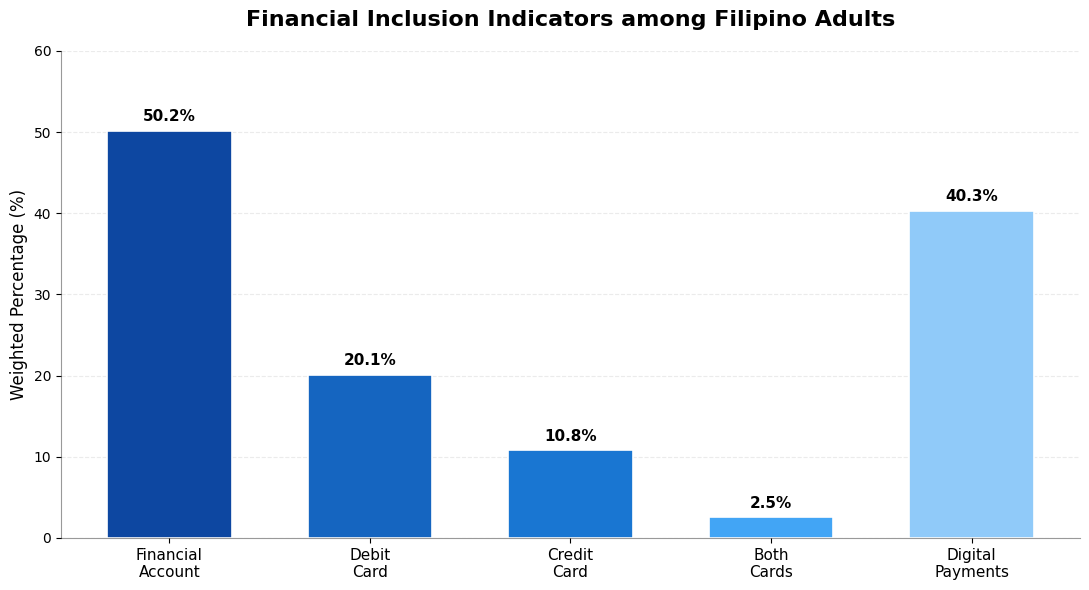

In [ ]:
import matplotlib.pyplot as plt

# Create shorter labels for the chart
chart_labels = ["Financial\nAccount","Debit\nCard","Credit\nCard","Both\nCards","Digital\nPayments"]

# Create a color palette for the bars
colors = ["#0D47A1","#1565C0","#1976D2","#42A5F5","#90CAF9"]

# Create the chart area
plt.figure(figsize=(11, 6))

# Create the bars
bars = plt.bar(chart_labels,financial_inclusion["Weighted Percentage"],color=colors,width=0.62,edgecolor="white",linewidth=1.2)

# Add the chart title
plt.title("Financial Inclusion Indicators among Filipino Adults",
    fontsize=16,
    fontweight="bold",
    pad=18)

# Add the y-axis label
plt.ylabel("Weighted Percentage (%)",fontsize=12)

# Set the y-axis range
plt.ylim(0, 60)

# Set the y-axis intervals
plt.yticks(range(0, 61, 10),fontsize=10)

# Format the x-axis labels
plt.xticks(fontsize=11)

# Add horizontal gridlines
plt.grid(axis="y",linestyle="--",alpha=0.25)

# Place the gridlines behind the bars
plt.gca().set_axisbelow(True)

# Remove unnecessary chart borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.4)
ax.spines["bottom"].set_alpha(0.4)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold")

# Adjust spacing to prevent labels from being cut off
plt.tight_layout()

# Display the chart
plt.show()

### Results and Discussion

The weighted analysis indicates the level of financial inclusion among Filipino adults based on the Global Findex 2025 survey.

**Financial account ownership serves as the primary measure of financial inclusion**, while **debit and credit card** ownership reflect access to formal banking products. The proportion of respondents with both debit and credit cards provides an **indication of broader engagement with financial services**. Digital payment usage measures the adoption of electronic financial transactions.

Overall, **these indicators establish the baseline level of financial inclusion** in the **Philippines** and provide the foundation for examining demographic differences in the succeeding analyses.

**# Research Question 2**

## How does financial inclusion differ across demographic groups in the Philippines?

## Objective

This section examines whether financial account ownership differs across demographic groups. The analysis compares financial inclusion by gender, age group, education level, employment status, income quintile, and place of residence using survey weighted percentages.

**Demographic Labels**

In [ ]:
# Gender
df["Gender"] = df["female"].map({1: "Female",2: "Male"})

# Employment
df["Employment"] = df["emp_in"].map({1: "In Workforce",2: "Out of Workforce"})

# Residence
df["Residence"] = df["urbanicity"].map({1: "Urban",2: "Rural"})

# Education
df["Education"] = df["educ"].map({1: "Primary or Less",2: "Secondary",3: "Tertiary"})

# Income Group
df["Income Group"] = df["inc_q"].map({1: "Poorest 20%",2: "Second 20%",3: "Middle 20%",4: "Fourth 20%",5: "Richest 20%"})

In [ ]:
##Age Groups
df["Age Group"] = pd.cut(df["age"],bins=[15, 25, 35, 45, 55, 65, 100],labels=["15-24","25-34","35-44","45-54","55-64","65+"],right=False)

In [ ]:
##Reusable Summary Function
def demographic_summary(df, group_column):
    summary = (df.groupby(group_column).apply(lambda x: weighted_percentage(x["account"] == 1,x["wgt"]),include_groups=False).reset_index(name="Financial Account Ownership (%)"))
    summary["Financial Account Ownership (%)"] = (summary["Financial Account Ownership (%)"].round(2))

    return summary

**Demographic factor**

In [ ]:
gender_results = demographic_summary(df, "Gender")
gender_results

,Gender,Financial Account Ownership (%)
0,Female,57.10
1,Male,43.04


In [ ]:
age_results = demographic_summary(df, "Age Group")
age_results

/tmp/ipykernel_2837/1367906743.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (df.groupby(group_column).apply(lambda x: weighted_percentage(x["account"] == 1,x["wgt"]),include_groups=False).reset_index(name="Financial Account Ownership (%)"))


,Age Group,Financial Account Ownership (%)
0,15-24,55.11
1,25-34,55.89
2,35-44,53.77
3,45-54,42.09
4,55-64,34.02
5,65+,45.32


In [ ]:
education_results = demographic_summary(df, "Education")
education_results

,Education,Financial Account Ownership (%)
0,Primary or Less,33.62
1,Secondary,53.34
2,Tertiary,82.15


In [ ]:
employment_results = demographic_summary(df, "Employment")
employment_results

,Employment,Financial Account Ownership (%)
0,In Workforce,54.12
1,Out of Workforce,44.33


In [ ]:
income_results = demographic_summary(df, "Income Group")
income_results

,Income Group,Financial Account Ownership (%)
0,Fourth 20%,62.13
1,Middle 20%,55.38
2,Poorest 20%,33.05
3,Richest 20%,64.47
4,Second 20%,35.82


In [ ]:
residence_results = demographic_summary(df, "Residence")
residence_results

,Residence,Financial Account Ownership (%)
0,Rural,56.57
1,Urban,46.46


# **Results & Findings**

**The analysis** shows that financial inclusion varies across several demographic groups in the Philippines.

**Education** level demonstrates the strongest relationship with financial account ownership. Respondents with **tertiary education have the highest weighted account ownership** **(82.15%)**, compared with **53.34% for those with secondary education** and **only 33.62% for those with primary education** or less. This suggests that higher educational attainment is strongly associated with greater participation in the formal financial system.

**Income** also has a substantial influence on financial inclusion. **Account ownership increases from 33.05%** among respondents in the **poorest income quintile to 64.47% among those in the richest quintile**. This indicates that **individuals with higher incomes are considerably more likely to own a financial account.**

**Age** differences are also evident. **Account ownership** is highest among respondents **aged 25–34 (55.89%)** and gradually **declines** among **older age groups**, **reaching 34.02% for those aged 55–64**. This pattern suggests that financial participation may vary across different stages of adulthood.

Employment status shows a moderate difference, with respondents in the workforce (54.12%) more likely to own a financial account than those outside the workforce (44.33%). Similarly, differences between urban and rural respondents are relatively modest compared with education and income.

**Overall, the findings indicate that education and income are the strongest demographic factors associated with financial account ownership among Filipino adults.**

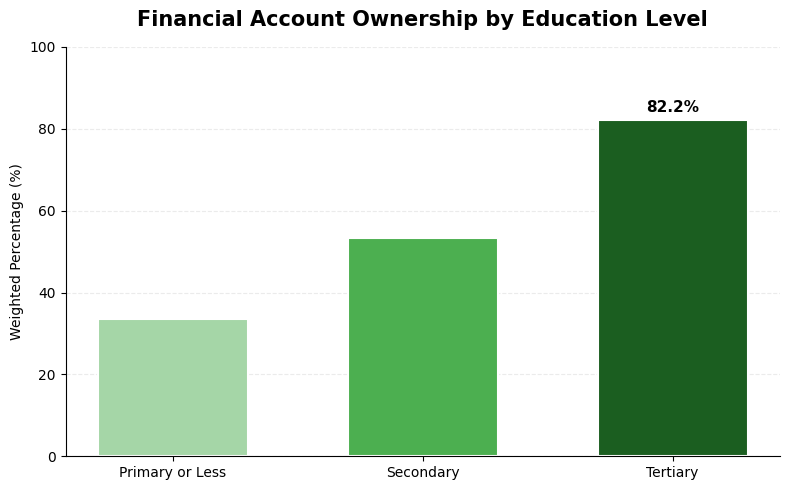

In [ ]:
##Education Chart
import matplotlib.pyplot as plt

education_order = ["Primary or Less","Secondary","Tertiary"]

education_chart = (education_results.set_index("Education").reindex(education_order).reset_index())

colors = [
    "#A5D6A7",
    "#4CAF50",
    "#1B5E20"]

plt.figure(figsize=(8,5))

bars = plt.bar(
education_chart["Education"],
education_chart["Financial Account Ownership (%)"],
color=colors,
edgecolor="white",
linewidth=1.5,
width=0.6)

plt.title("Financial Account Ownership by Education Level",fontsize=15,fontweight="bold",pad=15)

plt.ylabel("Weighted Percentage (%)")
plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.gca().set_axisbelow(True)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    value = bar.get_height()
plt.text(bar.get_x()+bar.get_width()/2,value+2,f"{value:.1f}%",ha="center",fontweight="bold",fontsize=11)

plt.tight_layout()
plt.show()


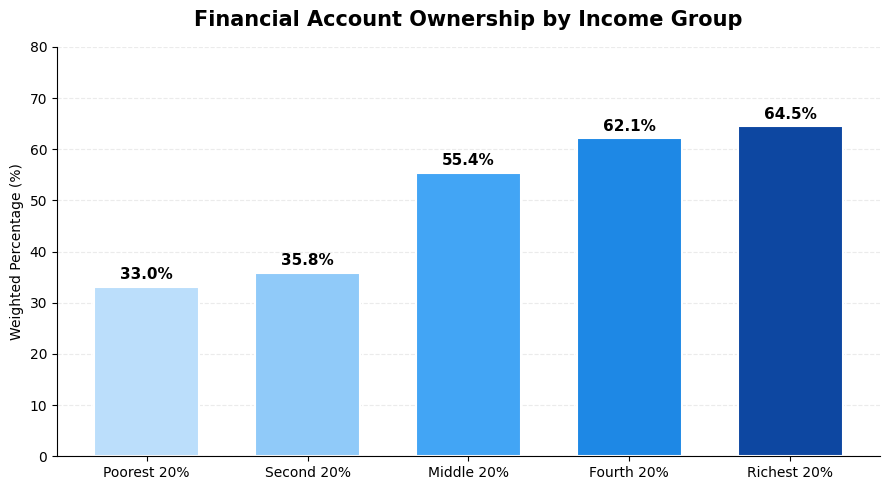

In [ ]:
##Income Chart
import matplotlib.pyplot as plt

income_order = [
    "Poorest 20%",
    "Second 20%",
    "Middle 20%",
    "Fourth 20%",
    "Richest 20%"]

income_chart = (
    income_results
    .set_index("Income Group")
    .reindex(income_order)
    .reset_index()
)

colors = [
    "#BBDEFB",
    "#90CAF9",
    "#42A5F5",
    "#1E88E5",
    "#0D47A1"]

plt.figure(figsize=(9,5))

bars = plt.bar(
    income_chart["Income Group"],
    income_chart["Financial Account Ownership (%)"],
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.65)

plt.title(
    "Financial Account Ownership by Income Group",
    fontsize=15,
    fontweight="bold",
    pad=15)

plt.ylabel("Weighted Percentage (%)")
plt.ylim(0,80)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.gca().set_axisbelow(True)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+1.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=11)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2837/1367906743.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (df.groupby(group_column).apply(lambda x: weighted_percentage(x["account"] == 1,x["wgt"]),include_groups=False).reset_index(name="Financial Account Ownership (%)"))


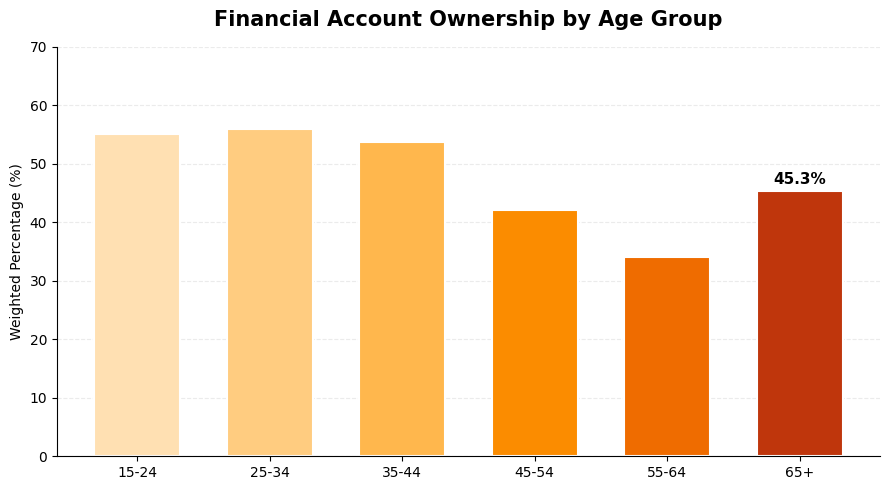

In [ ]:
#Age Group Chart

# Recreate the age groups using consistent labels
df["Age Group"] = pd.cut(
    df["age"],
    bins=[15, 25, 35, 45, 55, 65, 100],
    labels=[
        "15-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ],right=False)

# Recalculate the weighted account ownership by age group
age_results = demographic_summary(df, "Age Group")

# Arrange the groups from youngest to oldest
age_order = [
    "15-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"]

age_chart = (
    age_results
    .set_index("Age Group")
    .reindex(age_order)
    .reset_index())

# Colors for each age group
colors = [
    "#FFE0B2",
    "#FFCC80",
    "#FFB74D",
    "#FB8C00",
    "#EF6C00",
    "#BF360C"]

# Create the chart
plt.figure(figsize=(9, 5))

bars = plt.bar(
    age_chart["Age Group"],
    age_chart["Financial Account Ownership (%)"],
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.65)

plt.title(
    "Financial Account Ownership by Age Group",
    fontsize=15,
    fontweight="bold",
    pad=15)

plt.ylabel("Weighted Percentage (%)")
plt.xlabel("")
plt.ylim(0, 70)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25)

plt.gca().set_axisbelow(True)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add percentage labels above each bar
for bar in bars:value = bar.get_height()

plt.text(bar.get_x() + bar.get_width() / 2,value + 1.3,f"{value:.1f}%",ha="center",fontsize=11,fontweight="bold")

plt.tight_layout()
plt.show()

# **# Research Question 3**

##What factors are associated with digital payment adoption among Filipino adults?

### Objective

This section investigates how digital payment adoption varies across demographic groups in the Philippines. Using survey weighted percentages, the analysis compares digital payment usage by gender, age group, education level, employment status, income group, and place of residence.

In [ ]:
##Summary Table
#largest gap within each demographic factor
def demographic_digital_payment(df, group_column):

    summary = (df.groupby(group_column)
.apply(lambda x: weighted_percentage(
x["anydigpayment"] == 1,
x["wgt"]),include_groups=False).reset_index(name="Digital Payment Usage (%)"))

    summary["Digital Payment Usage (%)"] = (summary["Digital Payment Usage (%)"].round(2))

    return summary

In [ ]:
gender_dp = demographic_digital_payment(df, "Gender")
gender_dp

,Gender,Digital Payment Usage (%)
0,Female,45.7
1,Male,34.8


In [ ]:
age_dp = demographic_digital_payment(df, "Age Group")
age_dp

/tmp/ipykernel_2837/437380703.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (df.groupby(group_column)


,Age Group,Digital Payment Usage (%)
0,15-24,51.99
1,25-34,46.69
2,35-44,45.26
3,45-54,27.56
4,55-64,17.02
5,65+,25.92


In [ ]:
education_dp = demographic_digital_payment(df, "Education")
education_dp

,Education,Digital Payment Usage (%)
0,Primary or Less,21.52
1,Secondary,45.39
2,Tertiary,68.87


In [ ]:
employment_dp = demographic_digital_payment(df, "Employment")
employment_dp

,Employment,Digital Payment Usage (%)
0,In Workforce,42.31
1,Out of Workforce,37.40


In [ ]:
income_dp = demographic_digital_payment(df, "Income Group")
income_dp

,Income Group,Digital Payment Usage (%)
0,Fourth 20%,51.14
1,Middle 20%,46.71
2,Poorest 20%,17.57
3,Richest 20%,55.22
4,Second 20%,30.95


In [ ]:
residence_dp = demographic_digital_payment(df, "Residence")
residence_dp

,Residence,Digital Payment Usage (%)
0,Rural,51.82
1,Urban,33.63


In [ ]:
digital_summary = pd.DataFrame({
    "Demographic Factor": [
        "Education",
        "Income Group",
        "Age Group",
        "Employment",
        "Residence",
        "Gender"],"Highest (%)": [
        education_dp["Digital Payment Usage (%)"].max(),
        income_dp["Digital Payment Usage (%)"].max(),
        age_dp["Digital Payment Usage (%)"].max(),
        employment_dp["Digital Payment Usage (%)"].max(),
        residence_dp["Digital Payment Usage (%)"].max(),
        gender_dp["Digital Payment Usage (%)"].max()],
        "Lowest (%)": [
        education_dp["Digital Payment Usage (%)"].min(),
        income_dp["Digital Payment Usage (%)"].min(),
        age_dp["Digital Payment Usage (%)"].min(),
        employment_dp["Digital Payment Usage (%)"].min(),
        residence_dp["Digital Payment Usage (%)"].min(),
        gender_dp["Digital Payment Usage (%)"].min()]})

digital_summary["Difference (%)"] = (
digital_summary["Highest (%)"] -
digital_summary["Lowest (%)"]).round(2)

digital_summary = digital_summary.sort_values("Difference (%)",ascending=False)

digital_summary

,Demographic Factor,Highest (%),Lowest (%),Difference (%)
0,Education,68.87,21.52,47.35
1,Income Group,55.22,17.57,37.65
2,Age Group,51.99,17.02,34.97
4,Residence,51.82,33.63,18.19
5,Gender,45.70,34.80,10.90
3,Employment,42.31,37.40,4.91


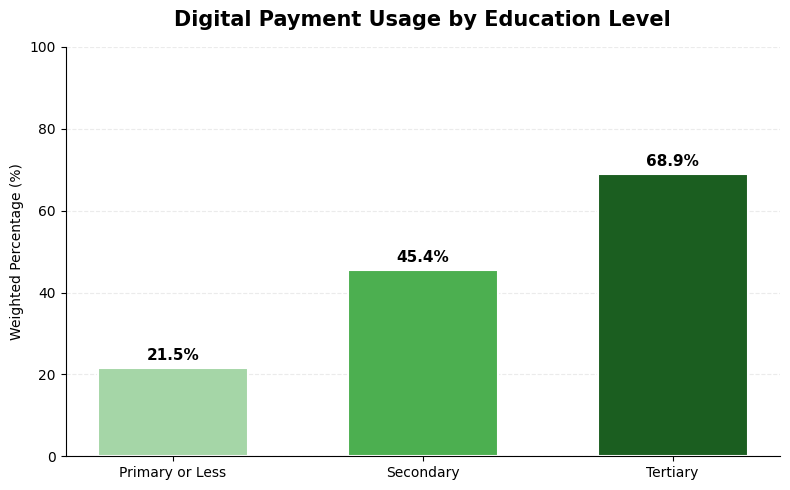

In [ ]:
import matplotlib.pyplot as plt

education_order = [
    "Primary or Less",
    "Secondary",
    "Tertiary"
]

education_chart = (
    education_dp
    .set_index("Education")
    .reindex(education_order)
    .reset_index()
)

colors = [
    "#A5D6A7",
    "#4CAF50",
    "#1B5E20"
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    education_chart["Education"],
    education_chart["Digital Payment Usage (%)"],
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.6
)

plt.title(
    "Digital Payment Usage by Education Level",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.ylabel("Weighted Percentage (%)")
plt.xlabel("")
plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.gca().set_axisbelow(True)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=11
    )

plt.tight_layout()
plt.show()

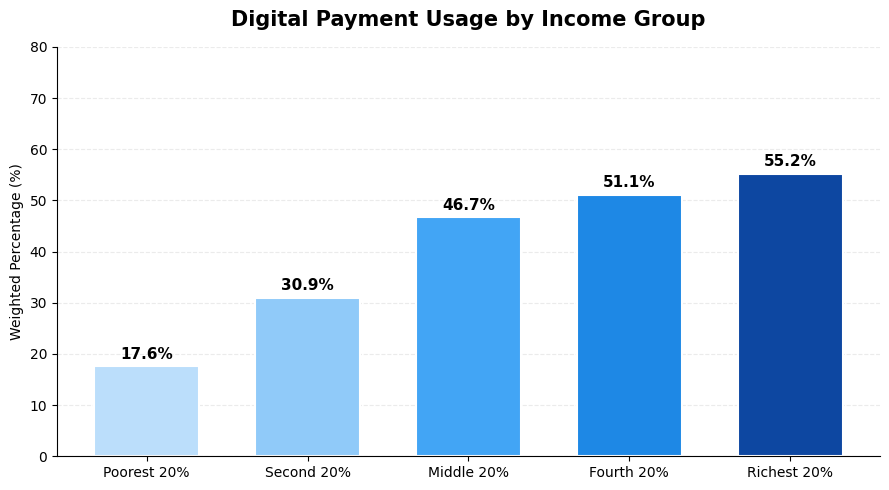

In [ ]:
import matplotlib.pyplot as plt

income_order = [
    "Poorest 20%",
    "Second 20%",
    "Middle 20%",
    "Fourth 20%",
    "Richest 20%"
]

income_chart = (
    income_dp
    .set_index("Income Group")
    .reindex(income_order)
    .reset_index()
)

colors = [
    "#BBDEFB",
    "#90CAF9",
    "#42A5F5",
    "#1E88E5",
    "#0D47A1"
]

plt.figure(figsize=(9,5))

bars = plt.bar(
    income_chart["Income Group"],
    income_chart["Digital Payment Usage (%)"],
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.65
)

plt.title(
    "Digital Payment Usage by Income Group",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.ylabel("Weighted Percentage (%)")
plt.xlabel("")
plt.ylim(0,80)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.gca().set_axisbelow(True)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+1.5,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=11
    )

plt.tight_layout()
plt.show()

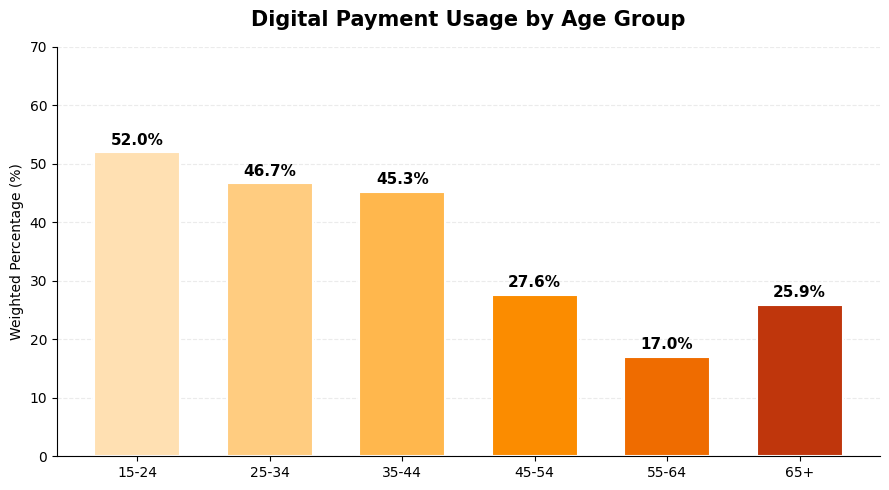

In [ ]:
import matplotlib.pyplot as plt

age_order = [
    "15-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"]

age_chart = (
    age_dp
    .set_index("Age Group")
    .reindex(age_order)
    .reset_index())

colors = [
    "#FFE0B2",
    "#FFCC80",
    "#FFB74D",
    "#FB8C00",
    "#EF6C00",
    "#BF360C"]

plt.figure(figsize=(9,5))

bars = plt.bar(
    age_chart["Age Group"],
    age_chart["Digital Payment Usage (%)"],
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    width=0.65)

plt.title(
    "Digital Payment Usage by Age Group",
    fontsize=15,
    fontweight="bold",
    pad=15)

plt.ylabel("Weighted Percentage (%)")
plt.xlabel("")
plt.ylim(0,70)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.gca().set_axisbelow(True)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+1.3,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=11
    )

plt.tight_layout()
plt.show()

## **Results and Discussion**

The analysis indicates that digital payment adoption varies across demographic groups in the Philippines. **Respondents with higher levels of education and higher household income tend to report greater use of digital payment services** than those with lower education and income levels.

**Differences are also observed across age groups**, suggesting that digital payment adoption varies by stage of life. Employment status, gender, and place of residence may also influence adoption, although the magnitude of these differences is generally smaller.

Overall, the **findings suggest that socioeconomic characteristics**, particularly **education, income and age**, are **closely associated with the adoption of digital financial services among Filipino adults.**

# Recommendations

Based on the findings of this analysis, the following recommendations may help support financial inclusion and digital payment adoption in the Philippines:

### 1. Expand financial education initiatives

Education showed the strongest difference in both financial account ownership and digital payment usage. Financial literacy programs should focus on individuals with primary education or less and explain basic financial products, account usage, digital payments, fees, and online safety in simple and accessible language.

### 2. Improve access for lower income groups

Respondents from lower income groups had substantially lower levels of account ownership and digital payment adoption. Financial institutions and public agencies could support low cost accounts, reduced transaction fees, simplified onboarding, and products designed for individuals with irregular or limited income.

### 3. Support older adults in adopting digital financial services

Digital payment usage was considerably lower among older respondents, particularly those aged 55–64. Banks and digital payment providers could offer guided onboarding, in person demonstrations, simplified mobile applications, and customer support designed for older users.

### 4. Encourage active account usage

Account ownership was higher than debit card ownership, credit card ownership, and digital payment usage. This suggests that some respondents may own an account without fully using available financial services. Programs should therefore focus not only on opening accounts but also on encouraging safe and practical use of debit cards and digital payments.

### 5. Strengthen digital safety and consumer protection

As digital financial services expand, users should also receive clear guidance on protecting passwords, recognizing scams, verifying transactions, and reporting unauthorized activity. Strong consumer protection can help improve trust and encourage continued usage.

### 6. Conduct further analysis using additional variables

Future studies could examine internet access, mobile phone ownership, barriers to account ownership, saving behavior, borrowing behavior, and financial resilience. These variables may provide a more complete explanation of the factors influencing financial inclusion.

## Final Recommendation

The findings suggest that financial inclusion initiatives should prioritize people with lower educational attainment, lower income, and older age groups. Improving access alone may not be sufficient; programs should also promote financial literacy, digital confidence, affordability, and safe usage of financial services.